In [1]:
from datetime import datetime, timedelta, UTC
import os
from pathlib import Path

import numpy as np
import pandas as pd
from feder import FlightQuery, BoundingBox
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Use test database.

In [2]:
os.environ["FEDER_DATA_DIR"] = str(Path.cwd().parent / 'tests/api/data')

Choose a time range to work with.

In [3]:
TSTART = datetime(2025, 5, 22, 0, 0, tzinfo=UTC)
TEND = TSTART + timedelta(hours=24)

Get all the flights in the test database in the given time range.

In [4]:
query = FlightQuery(TSTART, TEND).time_starts_in()
flights = list(query.run())
print(f"Queried {len(flights)} flights")

Queried 116 flights


In [5]:
min_lon = -100
max_lon = -80
min_lat = 30
max_lat = 45

Plot all trajectories and the bounding box we're going to work with.

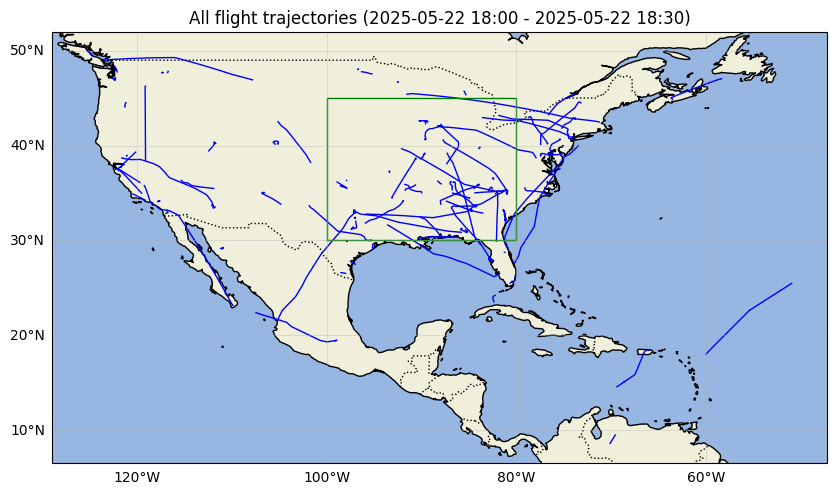

In [6]:
title = "All flight trajectories (2025-05-22 18:00 - 2025-05-22 18:30)"

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_facecolor("lightcyan")

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

for flight in flights:
    pts = pd.DataFrame(flight.points).sort_values("time")
    ax.plot(
        pts.lon, pts.lat,
        linewidth=1, color="blue",
        transform=ccrs.PlateCarree()
    )

ax.plot(
    [min_lon, max_lon, max_lon, min_lon, min_lon],
    [min_lat, min_lat, max_lat, max_lat, min_lat],
    color="green", linewidth=1,
    transform=ccrs.PlateCarree()
)

ax.set_title(title)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
gl.right_labels = False
gl.top_labels = False

plt.show()

Now we're going to look at the flights in the green box, splitting each trajectory into slices of 10 flight levels.

In [9]:
bounds = BoundingBox(min_lat, max_lat, min_lon, max_lon)

Start with a query without altitude information. We use the `filter_waypoints` method so that we only get the trajectory points within the additional  altitude bounds we're going to impose.

In [11]:
query = (
    FlightQuery(TSTART, TEND).
        time_starts_in().
        with_bounds(bounds).
        spatially_crosses().
        filter_waypoints()
)

Now we iterate over flight level slices, making a sub-query for each slice:

In [ ]:
fl_boundaries = np.arange(250, 410, 10)
for fl_min, fl_max in zip(fl_boundaries[:-1], fl_boundaries[1:]):
    sub_query = query.with_bounds(min_alt=fl_min * 100, max_alt=fl_max * 100)
    flights = list(sub_query.run())
    print(fl_min, fl_max, len(flights), sum(len(f.points) for f in flights))